## Problem 7.1 - K-nearest-neighbors

In [12]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from matplotlib.colors import LinearSegmentedColormap

In [13]:
# truncate the colormap RdPu (I just do that for aesthetic reasons)
truncated_RdPu = LinearSegmentedColormap.from_list('truncated_RdPu', plt.cm.RdPu(np.linspace(0.3, 0.8, 100))) 

### a) Fitting a 3-nearest-neighbor model

In [14]:
# generate and split data
X, y = make_classification(n_samples = 100, n_features = 2, n_redundant = 0, n_informative = 2, random_state = 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 3)

In [15]:
# fit the model
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


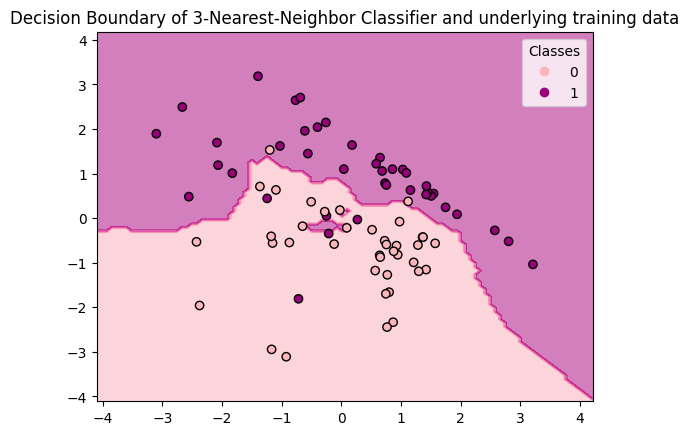

In [28]:
# plot the decision boundary
disp = DecisionBoundaryDisplay.from_estimator(
    knn, X,
    response_method = "predict",
    cmap = truncated_RdPu,
    alpha = 0.5
)

# plot also the training and test data points
scatterplot = plt.scatter(
    X_train[:, 0], X_train[:, 1],
    c = y_train,
    cmap = truncated_RdPu,
    edgecolor = 'k'
)
plt.title('Decision Boundary of 3-Nearest-Neighbor Classifier and underlying training data')
plt.legend(*scatterplot.legend_elements(), title = "Classes")
plt.show()

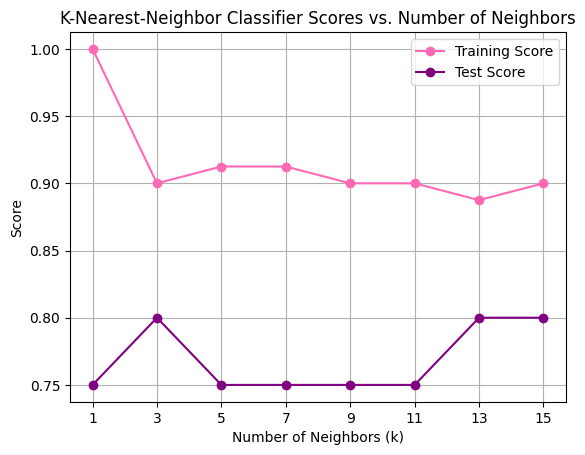

In [32]:
# scores of the model depending on the number of neighbors
neighbors = [1,3,5,7,9,11,13,15]
train_scores = []
test_scores = []
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

# plot the scores
plt.plot(neighbors, train_scores, label = 'Training Score', marker = 'o', color = 'hotpink')
plt.plot(neighbors, test_scores, label = 'Test Score', marker = 'o', color = 'purple')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Score')
plt.title('K-Nearest-Neighbor Classifier Scores vs. Number of Neighbors')
plt.xticks(neighbors)
plt.grid()
plt.legend()
plt.show()

### b) On 'KNeighborClassifier'

### c) writing and testing own KNN on a new point with unknown label

In [33]:
# define own KNN function

def own_knn(X_train, y_train, x_new, k):
    distances = np.linalg.norm(X_train - x_new, axis = 1)
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = y_train[nearest_indices]
    values, counts = np.unique(nearest_labels, return_counts = True)
    majority_label = values[np.argmax(counts)]
    return majority_label

In [35]:
# test own KNN function on a new point
x_new = X_test[0]
k = 3
predicted_label = own_knn(X_train, y_train, x_new, k)
print(f'The predicted label for the new point {x_new} using own KNN with k={k} is: {predicted_label}')
print(f"The true label was:", y_test[0])

The predicted label for the new point [-2.59347523 -2.28949135] using own KNN with k=3 is: 0
The true label was: 0


In [39]:
predictions = []
k = 3 

for x_new in X_test:
    pred = own_knn(X_train, y_train, x_new, k)
    predictions.append(pred)

predictions = np.array(predictions)

accuracy = np.mean(predictions == y_test)
print(f"Accuracy on the test set: {accuracy*100:.2f}%")

Accuracy on the test set: 80.00%
